# EV Flexibility Quantification

In this notebook we will look at how we can quantify the flexibility provided by a charging EV, considering grid flexibility needs signals, and process and comfort constraints. We'll see how the charging (and discharging, in the case of V2G) profile can be optimised to maximise the provided flexibility. We'll also look at different flexibility KPIs

Package imports

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import time
from math import pi
from matplotlib.colors import LinearSegmentedColormap

### Helper Functions

These functions assist in data manipulation and calculation of supporting parameters for the optimization. They include utilities for extending arrays, extracting user profiles, computing grid need signals (lambda spikes), and calculating a theoretical flexibility metric.

In [ ]:
def extend_to_Tplus(array_1d: np.ndarray) -> np.ndarray:
    """Duplicates the last element of a 1D array to match T+1 horizon dimensions."""
    if len(array_1d) == 0:
        return array_1d
    return np.append(array_1d, array_1d[-1])

def get_user_profile_for_session(df: pd.DataFrame, arrival: int, departure: int, start_day: int, stop_day: int) -> np.ndarray:
    """Extracts the inelastic load profile for the duration of the charging session."""
    if start_day == stop_day:
        return df.iloc[arrival:departure, start_day].values

    profile_part1 = df.iloc[arrival:96, start_day].values
    profile_part2 = df.iloc[0:departure, stop_day].values
    return np.concatenate([profile_part1, profile_part2])

def compute_lambda_spikes(arrival: int, departure: int, delta_t: float,
                          up_spike_frac: float, down_spike_frac: float,
                          up_spike_width: int, down_spike_width: int) -> tuple:
    """Computes up and down regulation signals (lambda) over the session horizon."""
    T_session = departure - arrival
    lambda_up = np.zeros(T_session)
    lambda_down = np.zeros(T_session)

    up_center = min(T_session - 1, max(0, int(round(up_spike_frac * T_session))))
    down_center = min(T_session - 1, max(0, int(round(down_spike_frac * T_session))))

    up_start = max(0, up_center - up_spike_width // 2)
    up_end = min(T_session, up_start + up_spike_width)

    down_start = max(0, down_center - down_spike_width // 2)
    down_end = min(T_session, down_start + down_spike_width)

    # Prioritize down spike if intervals overlap
    if max(up_start, down_start) < min(up_end, down_end):
        up_indices = (None, None)
    else:
        lambda_up[up_start:up_end] = 1.0
        up_indices = (up_start, up_end)

    lambda_down[down_start:down_end] = 1.0
    down_indices = (down_start, down_end)

    return lambda_up, lambda_down, up_indices, down_indices

def calc_flex_paper_method(connected_time_h: float, total_energy_kwh: float, P_max: float) -> float:
    """Calculates the theoretical flexibility metric based on ideal idle time."""
    charge_time_h = total_energy_kwh / P_max
    idle = connected_time_h - charge_time_h
    return 0.0 if idle <= 0 else P_max * idle

### Optimization Core

The `run_single_ev_optimisation` function defines and solves the convex optimization problem for a single EV charging/discharging session. It models power flow, battery state of charge, connection limits, and grid signals to optimize flexibility while meeting energy demand.

In [ ]:
def run_single_ev_optimisation(
        start_day: int, stop_day: int,
        arrival_idx: int, departure_idx: int,
        energy_needed_kwh: float,
        df_user_4000: pd.DataFrame,
        e_cap_kwh: float,
        params: dict,
        up_spike_frac: float = 0.7, down_spike_frac: float = 0.3,
        up_spike_width: int = 4, down_spike_width: int = 4
    ) -> dict:
    """Formulates and solves the convex optimization problem for a single EV session."""

    T = departure_idx - arrival_idx
    delta_t = params["delta_t"]
    P_max = params["P_max"]
    P_min = params["P_min"]
    connection_limit = params["connection_limit"]
    delta_max = params["delta_max"]
    eta_ch = params["eta_ch"]
    eta_dis = params["eta_dis"]
    cycling_penalty = params["cycling_penalty"]
    use_baseline = params["use_baseline"]

    P_inelastic = get_user_profile_for_session(
        df_user_4000, arrival_idx, departure_idx, start_day, stop_day)

    λ_up, λ_dn, _, _ = compute_lambda_spikes(
        arrival_idx, departure_idx, delta_t, up_spike_frac, down_spike_frac,
        up_spike_width, down_spike_width)

    # Baseline calculation
    P_baseline = np.zeros(T)
    if use_baseline:
        e_acc = 0.0
        for t in range(T):
            rem = energy_needed_kwh - e_acc
            if rem <= 0: break
            p_need = rem / delta_t
            p_conn = max(0, connection_limit - P_inelastic[t])
            p = min(P_max, p_need, p_conn)
            P_baseline[t] = p
            e_acc += p * delta_t

    # Decision variables
    P_new = cp.Variable(T)
    delta_pos = cp.Variable(T, nonneg=True)
    delta_neg = cp.Variable(T, nonneg=True)
    b_bin = cp.Variable(T, boolean=True)
    s_ch = cp.Variable(T, nonneg=True)
    s_dis = cp.Variable(T, nonneg=True)
    z_bin = cp.Variable(T, boolean=True)
    energy_EV = cp.Variable(T+1)

    constraints = []

    # Baseline deviation matching
    if use_baseline:
        constraints += [P_new - P_baseline == delta_pos - delta_neg]
    else:
        constraints += [P_new == delta_pos - delta_neg]

    # Big-M constraints for positive/negative deviation
    M_dev = 2 * P_max
    for t in range(T):
        lhs = (P_new[t] - P_baseline[t]) if use_baseline else P_new[t]
        constraints += [
            lhs <= M_dev * b_bin[t],
            lhs >= -M_dev * (1 - b_bin[t]),
            delta_pos[t] <= M_dev * b_bin[t],
            delta_neg[t] <= M_dev * (1 - b_bin[t])
        ]

    # Power bounds
    constraints += [P_new <= P_max, P_new >= P_min]

    # Big-M constraints for charge/discharge splitting
    M_split = P_max
    for t in range(T):
        constraints += [
            P_new[t] <= M_split * z_bin[t],
            -P_new[t] <= M_split * (1 - z_bin[t]),
            s_ch[t] <= M_split * z_bin[t],
            s_dis[t] <= M_split * (1 - z_bin[t])
        ]

    # Power balance
    constraints += [P_new == s_ch - s_dis]

    # State of Charge trajectory
    E_init = 0.0
    constraints += [energy_EV[0] == E_init]
    for t in range(T):
        constraints += [
            energy_EV[t+1] == energy_EV[t] + delta_t * (eta_ch * s_ch[t] - s_dis[t] / eta_dis)
        ]

    constraints += [energy_EV[T] >= E_init + energy_needed_kwh]
    for t in range(T+1):
        constraints += [energy_EV[t] <= e_cap_kwh, energy_EV[t] >= E_init]

    # Cumulative energy band
    lhs_energy = cp.sum([s_dis[t] / eta_dis - s_ch[t] * eta_ch for t in range(T)])
    constraints += [
        lhs_energy <= (E_init - 0.99 * (E_init + energy_needed_kwh)) / delta_t,
        lhs_energy >= (E_init - 1.01 * (E_init + energy_needed_kwh)) / delta_t
    ]

    # Connection limits and ramp rate
    for t in range(T):
        constraints += [
            P_inelastic[t] + P_new[t] <= connection_limit,
            P_inelastic[t] + P_new[t] >= -connection_limit
        ]

    for t in range(1, T):
        constraints += [cp.abs(P_new[t] - P_new[t-1]) <= delta_max]

    # Objective formulation
    objective = cp.Maximize(
        cp.sum(cp.multiply(λ_up, delta_pos) + cp.multiply(λ_dn, delta_neg)) * delta_t
        - cycling_penalty * cp.sum(s_ch + s_dis)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.HIGHS, verbose=False)

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        print("Optimization infeasible.")
        return None

    # Performance KPIs extraction
    P_opt = P_new.value
    flex_val = 0.0
    for t in range(T):
        ref = P_baseline[t] if use_baseline else 0.0
        if λ_dn[t] > 0:
            flex_val += max(ref - P_opt[t], 0) * delta_t
        if λ_up[t] > 0:
            flex_val += max(P_opt[t] - ref, 0) * delta_t

    connected_time = T * delta_t
    paper_flex = calc_flex_paper_method(connected_time, energy_needed_kwh, P_max)
    energy_absolute = float(np.sum(s_ch.value + s_dis.value) * delta_t)

    cap_up = np.maximum(P_max - P_baseline, 0.0)
    cap_dn = np.maximum(P_baseline - P_min, 0.0)
    flex_max_lambda = float((np.dot(λ_up, cap_up) + np.dot(λ_dn, cap_dn)) * delta_t)

    E_need_gross = energy_needed_kwh / eta_ch

    return {
        "time": extend_to_Tplus(np.arange(T) * delta_t),
        "Pinelastic": extend_to_Tplus(P_inelastic),
        "optimized": extend_to_Tplus(P_opt),
        "baseline": extend_to_Tplus(P_baseline) if use_baseline else None,
        "lambda_up": extend_to_Tplus(λ_up),
        "lambda_down": extend_to_Tplus(λ_dn),
        "energy_EV": energy_EV.value.flatten(),
        "objective_value": float(objective.value),
        "flex": flex_val,
        "paper_flex": paper_flex,
        "energy_absolute": energy_absolute,
        "energy_needed": energy_needed_kwh,
        "flex_max_lambda": flex_max_lambda,
        "ratio_flex_need": flex_val / energy_needed_kwh if energy_needed_kwh > 0 else 0.0,
        "ratio_flex_abs": flex_val / energy_absolute if energy_absolute > 0 else 0.0,
        "ratio_abs_need": energy_absolute / E_need_gross if E_need_gross > 0 else 0.0,
        "ratio_flex_lambda": flex_val / flex_max_lambda if flex_max_lambda > 0 else 0.0,
        "ratio_paperflex_to_realflex": paper_flex / flex_val if flex_val > 0 else 0.0,
        "beta_flex": flex_val / (connected_time * P_max) if (connected_time * P_max) > 0 else 0.0,
        "cycles": energy_absolute / e_cap_kwh
    }

### Scenario Configuration and Visualization Utilities

This section defines parameters for specific EV charging scenarios and provides functions to help visualize the optimization results, including shading grid need signal areas and plotting power/energy trajectories.

In [ ]:
# Base Configuration
delta_t = 0.25
arrival_time = 0
departure_time = int(10 / delta_t)
start_day = stop_day = 0
E_needed = 40.0
Pmax_val = 11.1
Cap_kWh = 60.0

up_center_h, down_center_h = 7.0, 3.0
spike_width_h = 1.0
up_spike_width = int(spike_width_h / delta_t)
down_spike_width = up_spike_width

T = departure_time - arrival_time
up_spike_frac = up_center_h / (T * delta_t)
down_spike_frac = down_center_h / (T * delta_t)

df_user_4000 = pd.DataFrame(np.zeros((96, 2)), columns=[0, 1])

In [ ]:

def _lighten(color: str, amount: float = 0.85) -> tuple:
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(1.0 - amount * (1.0 - rgb))

def shade_gns(ax: plt.Axes, down_range: tuple, up_range: tuple,
              style: str = "alpha", pastel: float = 0.9, hatch: str = '////'):
    """Shades the Grid Need Signal areas on the plot."""
    if style == "alpha":
        ax.axvspan(down_range[0], down_range[1], color="green", alpha=0.15, zorder=-10, label="_nolegend_")
        ax.axvspan(up_range[0], up_range[1], color="red", alpha=0.15, zorder=-10, label="_nolegend_")
    else:
        green = _lighten("green", pastel)
        red = _lighten("red", pastel)
        for r, col in zip([down_range, up_range], [green, red]):
            s = ax.axvspan(r[0], r[1], facecolor="none", edgecolor=col, hatch=hatch, linewidth=0.0, zorder=-10, label="_nolegend_")
            s.set_alpha(1.0)

def plot_gns_top(ax: plt.Axes, arrival_time: int, departure_time: int, delta_t: float,
                 up_spike_frac: float, down_spike_frac: float,
                 up_spike_width: int, down_spike_width: int):
    """Plots the GNS (lambda) signals on the top axis."""
    T = departure_time - arrival_time
    λ_up, λ_dn, up_indices, down_indices = compute_lambda_spikes(
        arrival_time, departure_time, delta_t, up_spike_frac, down_spike_frac, up_spike_width, down_spike_width
    )
    t_edge = np.arange(T + 1) * delta_t
    up_indices = (up_indices[0] * delta_t, up_indices[1] * delta_t)
    down_indices = (down_indices[0] * delta_t, down_indices[1] * delta_t)
    ax.step(t_edge, np.r_[λ_dn, λ_dn[-1]], where="post", color="green", linestyle="--", label=r"Ramp-down GNS")
    ax.step(t_edge, np.r_[λ_up, λ_up[-1]], where="post", color="red", linestyle="--", label=r"Ramp-up GNS")
    shade_gns(ax, down_indices, up_indices)
    ax.set_ylabel("GNS (–)")
    ax.set_xlim(0, T * delta_t)
    ax.grid(True, alpha=.3)
    ax.spines["top"].set_visible(False)
    return up_indices, down_indices

def plot_session_on_axis(ax: plt.Axes, session: dict, title: str, use_baseline: bool, up_indices: tuple, down_indices: tuple) -> tuple:
    """Plots the power usage and battery energy evolution over the session."""
    t = np.arange(len(session["optimized"])) * delta_t
    ln_baseline = None
    if use_baseline and session.get("baseline") is not None:
        ln_baseline = ax.step(t, session["baseline"], where="post", color="C0", linewidth=2, label="Baseline power")[0]

    ln_opt = ax.step(t, session["optimized"], where="post", color="C1", linewidth=2, label="Optimal power")[0]
    shade_gns(ax, down_indices, up_indices)
    ax.set_ylabel("Power (kW)")
    ax.grid(True, alpha=.3)

    ax2 = ax.twinx()
    ln_soc = ax2.plot(t, session["energy_EV"], color="purple", linestyle="-.", label="Energy EV")[0]
    ax2.set_ylabel("Energy (kWh)")
    return ln_baseline, ln_opt, ln_soc, ax2

def solve_scenario(mode: str, baseline_on: bool) -> dict:
    """Configures and runs an optimization scenario based on V1G/V2G and baseline preference."""
    params = {
        "delta_t": delta_t,
        "delta_max": 100.0,
        "connection_limit": 25.0,
        "eta_ch": 0.95,
        "eta_dis": 0.95,
        "cycling_penalty": 1e-3,
        "use_baseline": baseline_on,
        "P_max": Pmax_val,
        "P_min": 0.0 if mode == "V1G" else -Pmax_val
    }

    return run_single_ev_optimisation(
        start_day=start_day, stop_day=stop_day,
        arrival_idx=arrival_time, departure_idx=departure_time,
        energy_needed_kwh=E_needed, df_user_4000=df_user_4000,
        e_cap_kwh=Cap_kWh, params=params,
        up_spike_frac=up_spike_frac, down_spike_frac=down_spike_frac,
        up_spike_width=up_spike_width, down_spike_width=down_spike_width
    )

### Scenario Execution and Plot Generation

This section sets up the specific scenarios to be evaluated, runs the optimization for each, and then generates the multi-subplot visualization of the results, showing GNS, power profiles, and EV energy levels.

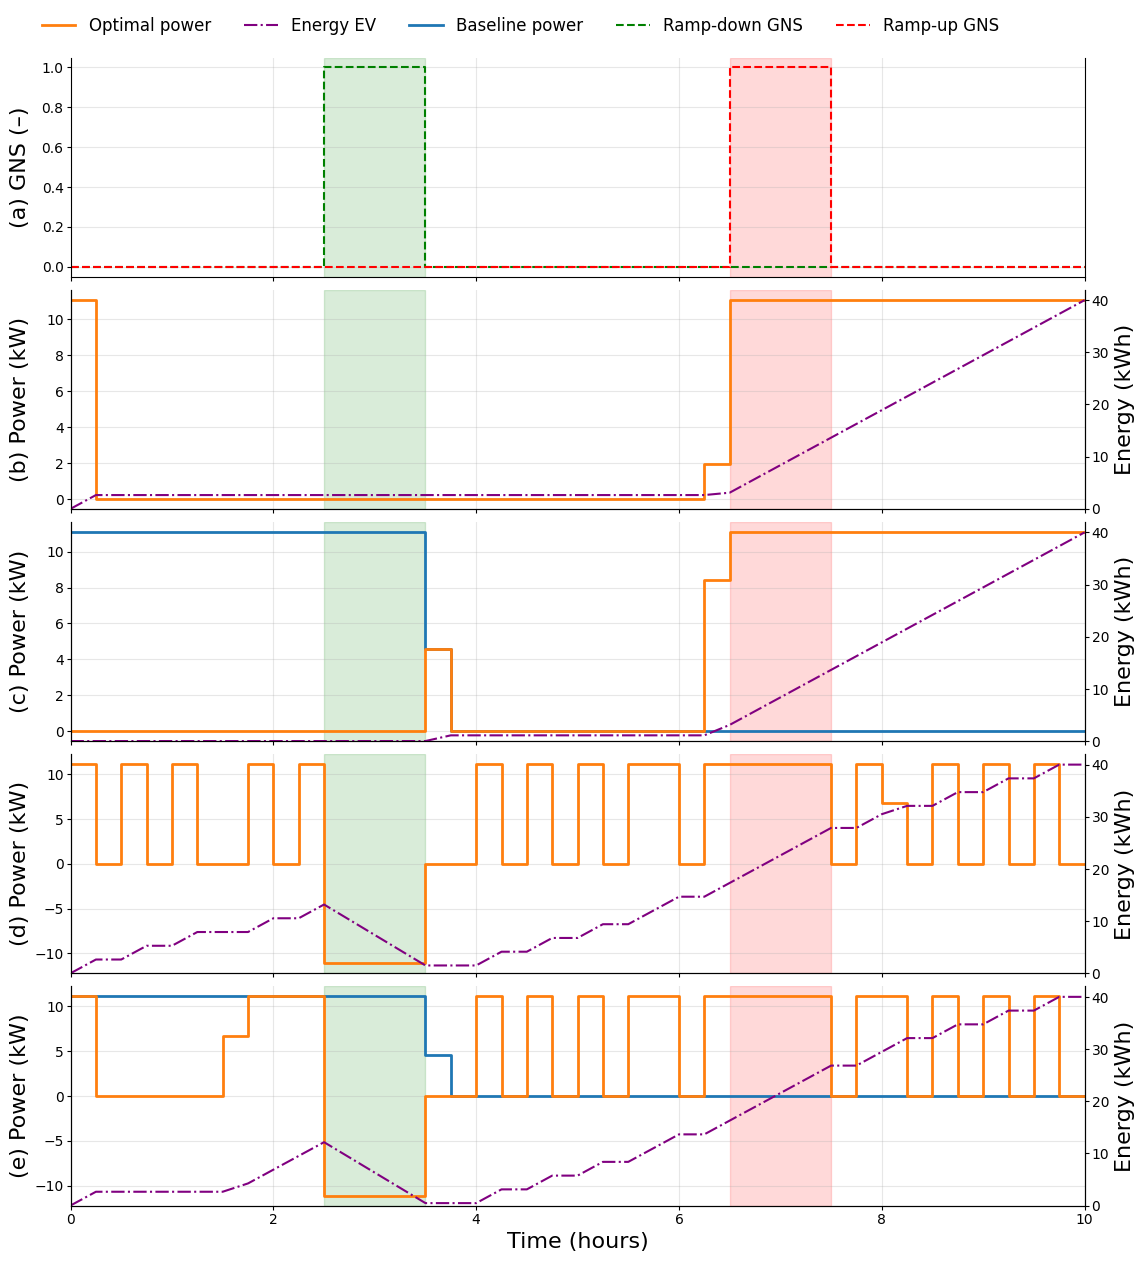

In [ ]:
scenarios = [
    ("(b) V1G (no baseline)",  "V1G", False),
    ("(c) V1G (baseline)",     "V1G", True),
    ("(d) V2G (no baseline)",  "V2G", False),
    ("(e) V2G (baseline)",     "V2G", True),
]

sessions = []
for title, mode, base in scenarios:
    s = solve_scenario(mode, base)
    if s is None:
        raise RuntimeError(f"Infeasible scenario: {title}")
    sessions.append((title, mode, base, s))

# Plot Generation
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

up_indices, down_indices = plot_gns_top(axes[0], arrival_time, departure_time, delta_t, up_spike_frac, down_spike_frac, up_spike_width, down_spike_width)

handles, labels = [], []
right_axes = []

for ax, (title, mode, base, sess) in zip(axes[1:], sessions):
    hb, ho, hs, ax2 = plot_session_on_axis(ax, sess, title=title, use_baseline=base, up_indices=up_indices, down_indices=down_indices)
    right_axes.append((ax2, sess))

    for h in (hb, ho, hs):
        if h is None: continue
        lab = h.get_label()
        if lab not in labels:
            handles.append(h); labels.append(lab)

for ax in axes: ax.spines["top"].set_visible(False)
for ax2, _ in right_axes: ax2.spines["top"].set_visible(False)

LABEL_FS = 16
letters  = ["(a)", "(b)", "(c)", "(d)", "(e)"]
axes[0].set_ylabel(f"{letters[0]} GNS (–)", fontsize=LABEL_FS)

for k, ax in enumerate(axes[1:], start=1):
    ax.set_ylabel(f"{letters[k]} Power (kW)", fontsize=LABEL_FS)

for ax2, _ in right_axes:
    ax2.set_ylabel("Energy (kWh)", fontsize=LABEL_FS)

for ax in axes:
    ax.yaxis.labelpad = 6
    ax.tick_params(axis="both", which="both", pad=2, length=3)
    ax.yaxis.set_label_coords(-0.04, 0.5)

axes[-1].set_xlabel("Time (hours)", fontsize=LABEL_FS)

for line in axes[0].lines[:2]:
    lab = line.get_label()
    if lab not in labels:
        handles.append(line); labels.append(lab)

fig.legend(handles, labels, loc="upper center", ncols=5, frameon=False, bbox_to_anchor=(0.5, 0.94), fontsize=12)
fig.subplots_adjust(top=0.90, bottom=0.08, hspace=0.06, right=0.97)

for k, ax in enumerate(axes):
    ax.set_title("")
    ax.yaxis.labelpad = 3
    ax.tick_params(axis="both", which="both", pad=2, length=3)
    ax.margins(x=0)
    if k < len(axes) - 1:
        ax.tick_params(labelbottom=False)

for ax2, sess in right_axes:
    soc = np.asarray(sess["energy_EV"])
    ax2.set_ylim(0.0, float(soc.max() * 1.05))
    ax2.yaxis.labelpad = 4
    ax2.tick_params(axis="y", which="both", pad=2, length=3)

plt.show()

## Sensitivity Analysis

### Individual Scenario Parameters

This section allows you to define specific parameters for a single EV charging/discharging scenario. Instead of sweeping through multiple values, you can set a fixed value for each parameter to analyze a particular case.

In [ ]:
# Define individual scenario parameters

connection_limit      = 25.0  # kW (max household power)
eta_ch                = 0.95  # pu (charging efficiency)
eta_dis               = 0.95  # pu (discharging efficiency)
cycling_penalty       = 1e-3  # battery degradation

E_init                = 0.0   # kWh (starting battery charge)
energy_cap            = 60.0  # kWh (e.g., 20, 40, 60, 80, 100)
percentage_requested  = 80    # % (e.g., 20, 30, ..., 90)
P_max                 = 7.4  # kW (e.g., 2.3, 3.7, 7.4, 11.1, 22.2)
use_baseline          = False  # True or False
mode_choice           = 'V1G' # 'V1G' or 'V2G'

start_day_of_year     = 1     # starting day (not relevant do not change)
arrival_time          = 0     # starting timestep
departure_time        = 13 * 4# final time step

lambda_up_fixed       = 0.3   # location of 'up' signal as ratio of full simulation time
lambda_down_fixed     = 0.7   # location of 'down' signal as ratio of full simulation time

# Derived parameters for the single scenario
energy_consumed = energy_cap * (percentage_requested / 100.0) - E_init
P_min_scenario = -P_max if mode_choice == 'V2G' else 0.0


### Execute Single Optimization Scenario

This cell executes the `run_single_ev_optimisation` function with the individually defined parameters from the previous cell.

In [ ]:
# Configure parameters for the single optimization run

params_single_run = {
    "delta_t": 0.25,
    "delta_max": 100,
    "connection_limit": connection_limit,
    "eta_ch": eta_ch,
    "eta_dis": eta_dis,
    "cycling_penalty": cycling_penalty,
    "use_baseline": use_baseline,
    "P_max": P_max,
    "P_min": P_min_scenario
}

# Run the optimization for the single scenario
single_session_result = run_single_ev_optimisation(
    start_day            = start_day_of_year,
    stop_day             = start_day_of_year,
    arrival_idx          = arrival_time,
    departure_idx        = departure_time,
    energy_needed_kwh    = energy_consumed,
    df_user_4000         = df_user_4000,
    e_cap_kwh            = energy_cap,
    params               = params_single_run,
    up_spike_frac        = lambda_up_fixed,
    down_spike_frac      = lambda_down_fixed,
    up_spike_width       = up_spike_width,
    down_spike_width     = down_spike_width
)

if single_session_result is None:
    print("Optimization for single scenario was infeasible.")
else:
    print("Optimization for single scenario completed successfully.")
    # Display some key results
    print(f"  Flexibility achieved: {single_session_result['flex']:.2f} kWh")
    print(f"  Cycles: {single_session_result['cycles']:.2f}")


Optimization for single scenario completed successfully.
  Flexibility achieved: 7.40 kWh
  Cycles: 0.84


### Visualize Single Optimization Result

This section plots the power profile and battery energy trajectory for the single optimization run. This visualization helps in understanding the EV's behavior under the chosen parameters.

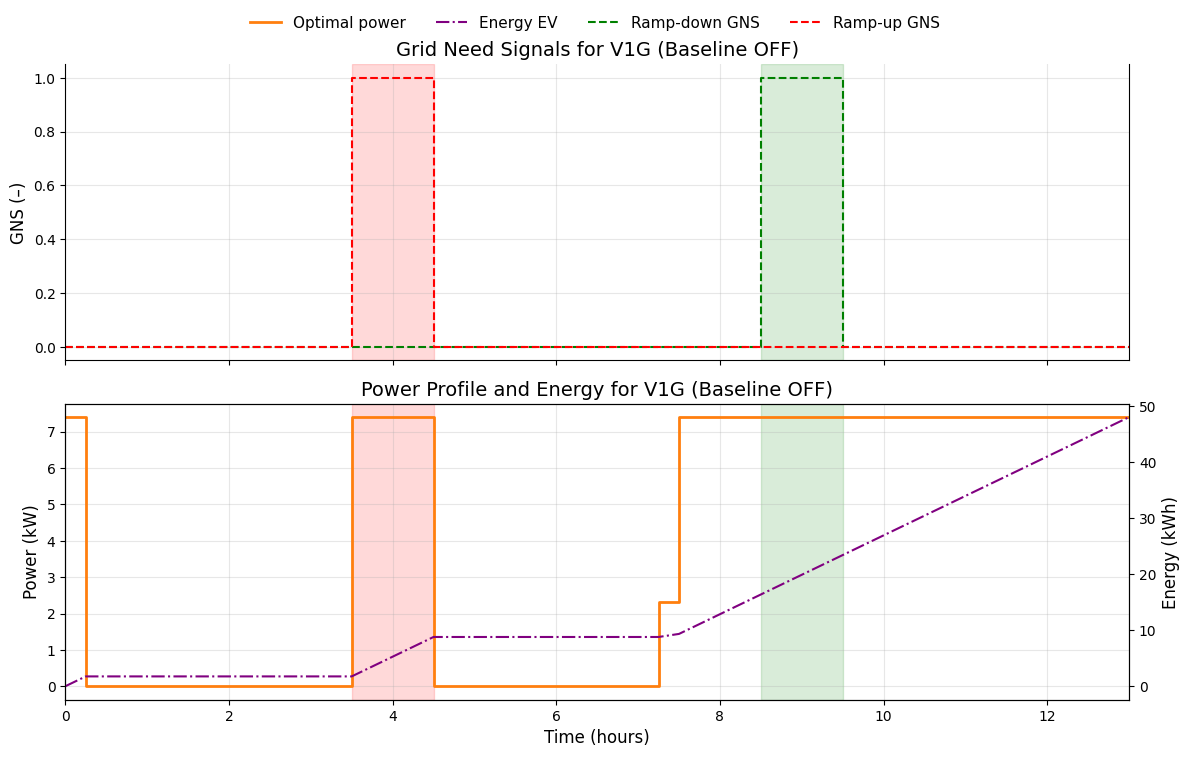

In [ ]:
if single_session_result is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot GNS on the top subplot
    up_indices, down_indices = plot_gns_top(axes[0], arrival_time, departure_time, delta_t, lambda_up_fixed, lambda_down_fixed, up_spike_width, down_spike_width)

    # Plot power and energy on the bottom subplot
    ln_baseline, ln_opt, ln_soc, ax2 = plot_session_on_axis(
        axes[1], single_session_result, title="Single Scenario Optimization", use_baseline=use_baseline, up_indices=up_indices, down_indices=down_indices
    )

    # Customize plot for single scenario
    axes[0].set_title(f"Grid Need Signals for {mode_choice} (Baseline {'ON' if use_baseline else 'OFF'})", fontsize=14)
    axes[1].set_title(f"Power Profile and Energy for {mode_choice} (Baseline {'ON' if use_baseline else 'OFF'})", fontsize=14)
    axes[1].set_xlabel("Time (hours)", fontsize=12)
    axes[0].set_ylabel("GNS (–)", fontsize=12)
    axes[1].set_ylabel("Power (kW)", fontsize=12)
    ax2.set_ylabel("Energy (kWh)", fontsize=12)

    # Create a single legend
    handles = []
    labels = []
    if ln_baseline: handles.append(ln_baseline); labels.append(ln_baseline.get_label())
    handles.append(ln_opt); labels.append(ln_opt.get_label())
    handles.append(ln_soc); labels.append(ln_soc.get_label())
    # Add GNS labels
    for line in axes[0].lines[:2]: # Assuming first two lines are lambda up/down
        lab = line.get_label()
        if lab not in labels:
            handles.append(line); labels.append(lab)

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncols=5, frameon=False, fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No results to plot as optimization was infeasible.")

### Parameter Sweep

The following code performs a sweep of different values for different parameters, providing a more complete sensitivity analysis. Code is commented, only uncomment and run after a few executions with different parameter variations of the cells above (Warning: execution is slow)

In [ ]:
# # =============================================================================
# # SENSITIVITY ANALYSIS EXECUTION
# # =============================================================================

# delta_t          = 0.25
# delta_max        = 100.0
# connection_limit = 25.0
# eta_ch           = 0.95
# eta_dis          = 0.95
# cycling_penalty  = 1e-3

# np.random.seed(42)
# df_user_4000 = pd.DataFrame(
#     data=np.random.rand(96, 2) * 1.0,
#     columns=[0, 1]
# )

# start_day_of_year = 1
# arrival_time      = 0
# departure_time    = 13 * 4

# energy_cap_list           = [20, 40, 60, 80, 100]
# percentage_requested_list = [20, 30, 40, 50, 60, 70, 80, 90]
# P_max_list                = [2.3, 3.7, 7.4, 11.1, 22.2]
# baseline_options          = [True, False]

# lambda_up_fixed   = 0.7
# lambda_down_fixed = 0.3

# up_spike_width   = int(1 / delta_t)
# down_spike_width = up_spike_width

# all_scenarios_results = []
# scenario_id = 1
# t_start = time.perf_counter()

# for mode in ['V2G', 'V1G']:
#     for e_cap in energy_cap_list:
#         for pct_req in percentage_requested_list:
#             E_init = 0.0
#             energy_consumed = e_cap * (pct_req / 100.0) - E_init

#             for P_max_val in P_max_list:
#                 P_max = P_max_val
#                 P_min = -P_max_val if mode == 'V2G' else 0.0

#                 for use_baseline in baseline_options:

#                     params_sens = {
#                         "delta_t": delta_t,
#                         "delta_max": delta_max,
#                         "connection_limit": connection_limit,
#                         "eta_ch": eta_ch,
#                         "eta_dis": eta_dis,
#                         "cycling_penalty": cycling_penalty,
#                         "use_baseline": use_baseline,
#                         "P_max": P_max,
#                         "P_min": P_min
#                     }

#                     session = run_single_ev_optimisation(
#                         start_day            = start_day_of_year,
#                         stop_day             = start_day_of_year,
#                         arrival_idx          = arrival_time,
#                         departure_idx        = departure_time,
#                         energy_needed_kwh    = energy_consumed,
#                         df_user_4000         = df_user_4000,
#                         e_cap_kwh            = e_cap,
#                         params               = params_sens,
#                         up_spike_frac        = lambda_up_fixed,
#                         down_spike_frac      = lambda_down_fixed,
#                         up_spike_width       = up_spike_width,
#                         down_spike_width     = down_spike_width
#                     )

#                     record = {
#                         "scenario_id":           scenario_id,
#                         "mode":                  mode,
#                         "energy_cap":            e_cap,
#                         "percentage_requested":  pct_req,
#                         "energy_consumed":       energy_consumed,
#                         "P_max":                 P_max,
#                         "P_min":                 P_min,
#                         "use_baseline":          use_baseline,
#                         "up_spike_frac":         lambda_up_fixed,
#                         "down_spike_frac":       lambda_down_fixed,
#                         "up_spike_width":        up_spike_width,
#                         "down_spike_width":      down_spike_width,
#                     }

#                     if session is not None:
#                         record.update({
#                             "flex":              session["flex"],
#                             "ratio_abs_need":    session["ratio_abs_need"],
#                             "ratio_flex_lambda": session["ratio_flex_lambda"],
#                             "cycles":            session["cycles"]
#                         })
#                     else:
#                         record.update({
#                             "flex":              np.nan,
#                             "ratio_abs_need":    np.nan,
#                             "ratio_flex_lambda": np.nan,
#                             "cycles":            np.nan
#                         })

#                     all_scenarios_results.append(record)
#                     scenario_id += 1

# t_end = time.perf_counter()
# print(f"Total scenarios run: {len(all_scenarios_results)}")
# print(f"Sensitivity analysis took {t_end - t_start:.1f} s")

# # =============================================================================
# # VISUALIZATION EXECUTION
# # =============================================================================

# df = pd.DataFrame(all_scenarios_results)

# # -----------------------------------------------------------------------------
# # 1. REGULAR HEATMAPS
# # -----------------------------------------------------------------------------
# print("\nGenerating Regular Heatmaps...")

# lambda_pairs     = [(0.7, 0.3)]
# # Fallback in case baseline_options array was defined differently earlier
# baseline_options_list = list(sorted(df["use_baseline"].dropna().unique()))

# kpi_specs = [
#     ("flex",              r"$E^{\mathrm{flex}}$"),
#     ("ratio_abs_need",    r"$\mathrm{ratio\_abs\_need}$"),
#     ("ratio_flex_lambda", r"$\mathrm{ratio\_flex\_lambda}$"),
#     ("cycles",            r"$n_{\mathrm{cycle}}$"),
# ]

# for mode in df["mode"].dropna().unique():
#     for Ecap in sorted(df["energy_cap"].dropna().unique()):
#         for kpi_col, kpi_title in kpi_specs:

#             nrows = len(lambda_pairs)
#             ncols = max(1, len(baseline_options_list))
#             fig, axes = plt.subplots(
#                 nrows=nrows, ncols=ncols,
#                 figsize=(6*ncols, 5*nrows),
#                 sharex=True, sharey=True
#             )
#             if nrows == 1 and ncols == 1:
#                 axes = np.array([[axes]])
#             elif nrows == 1:
#                 axes = np.array([axes])
#             elif ncols == 1:
#                 axes = np.array([[ax] for ax in axes])

#             pivots = {}
#             for i, (up_frac, down_frac) in enumerate(lambda_pairs):
#                 for j, use_baseline in enumerate(baseline_options_list):
#                     sub = df[
#                         (df["mode"]            == mode) &
#                         (df["energy_cap"]      == Ecap) &
#                         (df["use_baseline"]    == use_baseline) &
#                         (df["up_spike_frac"]   == up_frac) &
#                         (df["down_spike_frac"] == down_frac)
#                     ]
#                     if sub.empty or kpi_col not in sub.columns:
#                         pivots[(i, j)] = None
#                         continue
#                     piv = (
#                         sub.pivot(index="percentage_requested",
#                                   columns="P_max",
#                                   values=kpi_col)
#                            .sort_index(ascending=False)
#                     )
#                     pivots[(i, j)] = piv

#             all_vals = np.concatenate([
#                 p.values.ravel() for p in pivots.values() if p is not None
#             ]) if any(p is not None for p in pivots.values()) else np.array([])
#             if all_vals.size:
#                 vmin = float(np.nanmin(all_vals))
#                 vmax = float(np.nanmax(all_vals))
#                 if vmin == vmax:
#                     vmin, vmax = vmin - 1e-6, vmax + 1e-6
#             else:
#                 vmin, vmax = 0.0, 1.0

#             for i, (up_frac, down_frac) in enumerate(lambda_pairs):
#                 for j, use_baseline in enumerate(baseline_options_list):
#                     ax = axes[i, j]
#                     piv = pivots[(i, j)]
#                     if piv is None:
#                         ax.axis("off")
#                         ax.set_title(
#                             f"baseline={'on' if use_baseline else 'off'}"
#                         )
#                         continue

#                     annot = piv.round(2).astype(str)

#                     sns.heatmap(
#                         piv,
#                         annot=annot, fmt="",
#                         cmap="viridis",
#                         vmin=vmin, vmax=vmax,
#                         cbar=True,
#                         linewidths=0.5,
#                         ax=ax
#                     )

#                     ax.set_title(
#                         f"baseline={'on' if use_baseline else 'off'}"
#                     )
#                     ax.set_ylabel("Requested (%)" if j == 0 else "")
#                     ax.set_xlabel("$P_{max}$ (kW)" if i == nrows - 1 else "")

#             fig.suptitle(f"{kpi_title} | {mode} | E_cap={Ecap} kWh", fontsize=18, y=0.98)
#             plt.tight_layout(rect=[0, 0, 1, 0.95])
#             plt.show()

# # -----------------------------------------------------------------------------
# # 2. BASELINE ON-OFF DIFFERENCE HEATMAPS
# # -----------------------------------------------------------------------------
# print("\nGenerating Baseline ON-OFF Difference Heatmaps...")

# cmap_bgr = LinearSegmentedColormap.from_list(
#     "blue_grey_red",
#     [(0.0, "blue"), (0.5, "lightgrey"), (1.0, "red")]
# )

# pairs_in_df = (
#     df.loc[:, ["up_spike_frac", "down_spike_frac"]]
#       .dropna().drop_duplicates()
#       .apply(tuple, axis=1).tolist()
# )
# if not pairs_in_df:
#     pairs_in_df = [(0.7, 0.3)]
# pairs_in_df = sorted(pairs_in_df)

# for mode in df["mode"].dropna().unique():
#     for Ecap in sorted(df["energy_cap"].dropna().unique()):

#         plot_items = []
#         diff_tables = []
#         abs_tables  = []

#         for up_frac, down_frac in pairs_in_df:
#             sub_off = df[
#                 (df["mode"]==mode) & (df["energy_cap"]==Ecap) &
#                 (df["use_baseline"]==False) &
#                 (df["up_spike_frac"]==up_frac) & (df["down_spike_frac"]==down_frac)
#             ]
#             sub_on  = df[
#                 (df["mode"]==mode) & (df["energy_cap"]==Ecap) &
#                 (df["use_baseline"]==True) &
#                 (df["up_spike_frac"]==up_frac) & (df["down_spike_frac"]==down_frac)
#             ]

#             def _pivot(block, col):
#                 return (block.pivot(index="percentage_requested", columns="P_max", values=col)
#                              .sort_index(ascending=False))

#             if not sub_on.empty and not sub_off.empty:
#                 flex_on  = _pivot(sub_on,  "flex")
#                 flex_off = _pivot(sub_off, "flex")
#                 df_diff  = (flex_on - flex_off).reindex_like(flex_on)

#                 plot_items.append({
#                     "type": "diff", "pair": (up_frac, down_frac),
#                     "table": df_diff, "annot": df_diff.round(1).astype(str)
#                 })
#                 diff_tables.append(df_diff.values)
#             else:
#                 sub_any = sub_on if not sub_on.empty else sub_off
#                 if sub_any.empty: continue

#                 pivot_flex = _pivot(sub_any, "flex")
#                 pivot_cyc  = _pivot(sub_any, "cycles")
#                 pivot_abs  = _pivot(sub_any, "ratio_abs_need")

#                 plot_items.append({
#                     "type": "abs", "pair": (up_frac, down_frac),
#                     "baseline": "on" if not sub_on.empty else "off",
#                     "table": pivot_flex,
#                     "annot": (pivot_flex.round(2).astype(str) + "\n(" +
#                               pivot_cyc.round(2).astype(str) + ")\n[" +
#                               pivot_abs.round(2).astype(str) + "]")
#                 })
#                 abs_tables.append(pivot_flex.values)

#         if not plot_items: continue

#         m = float(np.nanmax(np.abs(np.concatenate([t.ravel() for t in diff_tables])))) if diff_tables else 0.0

#         if abs_tables:
#             abs_all = np.concatenate([t.ravel() for t in abs_tables])
#             vmin_abs, vmax_abs = float(np.nanmin(abs_all)) if abs_all.size else 0.0, float(np.nanmax(abs_all)) if abs_all.size else 1.0
#         else:
#             vmin_abs, vmax_abs = 0.0, 1.0

#         n = len(plot_items)
#         fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharex=True, sharey=True)
#         if n == 1: axes = np.array([axes])

#         for k, item in enumerate(plot_items):
#             ax, tbl, annot, (up, dn) = axes[k], item["table"], item["annot"], item["pair"]

#             if item["type"] == "diff":
#                 if m == 0.0 or tbl.isna().all().all():
#                     ax.axis("off")
#                     ax.set_title(f"λ=({up:.1f},{dn:.1f}) | on−off\n(no diff data)")
#                     continue
#                 sns.heatmap(tbl, annot=annot, fmt="", cmap=cmap_bgr, vmin=-m, vmax=+m, cbar=True, linewidths=0.5, ax=ax)
#                 ax.set_title(f"baseline on−off")
#             else:
#                 sns.heatmap(tbl, annot=annot, fmt="", cmap="viridis", vmin=vmin_abs, vmax=vmax_abs, cbar=True, linewidths=0.5, ax=ax)
#                 ax.set_title(f"baseline {item['baseline']}")

#             ax.set_xlabel("$P_{max}$ (kW)")
#             ax.set_ylabel("Requested (%)" if k == 0 else "")

#         fig.suptitle(f"{mode} | E_cap={Ecap} kWh", fontsize=16, y=0.98)
#         plt.tight_layout(rect=[0, 0, 1, 0.95])
#         plt.show()

# # -----------------------------------------------------------------------------
# # 3. BASELINE ON-OFF DIFFERENCE HEATMAPS VS E_CAP (P_max fixed)
# # -----------------------------------------------------------------------------
# print("\nGenerating Difference Heatmaps vs E_cap...")

# METRIC     = "flex"
# P_MAX_LIST = sorted(df["P_max"].dropna().unique())

# for mode in df["mode"].dropna().unique():
#     for Pfix in P_MAX_LIST:
#         plot_items, diff_tables, abs_tables = [], [], []

#         for up_frac, down_frac in pairs_in_df:
#             sub_off = df[(df["mode"]==mode) & (df["P_max"]==Pfix) & (df["use_baseline"]==False) &
#                          (df["up_spike_frac"]==up_frac) & (df["down_spike_frac"]==down_frac)]
#             sub_on  = df[(df["mode"]==mode) & (df["P_max"]==Pfix) & (df["use_baseline"]==True) &
#                          (df["up_spike_frac"]==up_frac) & (df["down_spike_frac"]==down_frac)]

#             def _pivot_ecap(block, col):
#                 return (block.pivot(index="percentage_requested", columns="energy_cap", values=col)
#                              .sort_index(ascending=False).sort_index(axis=1))

#             if not sub_on.empty and not sub_off.empty:
#                 on, off = _pivot_ecap(sub_on, METRIC), _pivot_ecap(sub_off, METRIC)
#                 on, off = on.align(off, join="outer")
#                 df_diff = on - off
#                 plot_items.append({"type": "diff", "table": df_diff, "annot": df_diff.round(1).astype(str)})
#                 diff_tables.append(df_diff.values)
#             else:
#                 sub_any = sub_on if not sub_on.empty else sub_off
#                 if sub_any.empty: continue
#                 tbl_metric = _pivot_ecap(sub_any, METRIC)
#                 tbl_cyc    = _pivot_ecap(sub_any, "cycles")
#                 tbl_abs    = _pivot_ecap(sub_any, "ratio_abs_need")
#                 plot_items.append({
#                     "type": "abs", "which": "on" if not sub_on.empty else "off",
#                     "table": tbl_metric,
#                     "annot": (tbl_metric.round(2).astype(str) + "\n(" + tbl_cyc.round(2).astype(str) + ")\n[" + tbl_abs.round(2).astype(str) + "]")
#                 })
#                 abs_tables.append(tbl_metric.values)

#         if not plot_items: continue

#         m = float(np.nanmax(np.abs(np.concatenate([t.ravel() for t in diff_tables])))) if diff_tables else 0.0
#         if abs_tables:
#             abs_all = np.concatenate([t.ravel() for t in abs_tables])
#             vmin_abs, vmax_abs = float(np.nanmin(abs_all)), float(np.nanmax(abs_all))
#         else:
#             vmin_abs, vmax_abs = 0.0, 1.0

#         n = len(plot_items)
#         fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharex=True, sharey=True)
#         if n == 1: axes = np.array([axes])

#         for k, item in enumerate(plot_items):
#             ax, tbl, annot = axes[k], item["table"], item["annot"]

#             if item["type"] == "diff":
#                 if m == 0.0 or tbl.isna().all().all():
#                     ax.axis("off")
#                     ax.set_title("baseline on−off\n(no diff data)")
#                 else:
#                     sns.heatmap(tbl, annot=annot, fmt="", cmap=cmap_bgr, vmin=-m, vmax=+m, center=0.0, cbar=True, linewidths=0.5, linecolor="white", ax=ax)
#                     ax.set_title("baseline on−off")
#             else:
#                 sns.heatmap(tbl, annot=annot, fmt="", cmap="viridis", vmin=vmin_abs, vmax=vmax_abs, cbar=True, linewidths=0.5, linecolor="white", ax=ax)
#                 ax.set_title(f"baseline {item['which']}")

#             ax.set_xlabel(r"$E^{\mathrm{cap}}$ (kWh)")
#             ax.set_ylabel("Requested (%)" if k == 0 else "")

#         fig.suptitle(f"{mode} | $P_{{\\max}}={Pfix}$ kW", fontsize=16, y=0.98)
#         plt.tight_layout(rect=[0, 0, 1, 0.95])
#         plt.show()

# # -----------------------------------------------------------------------------
# # 4. ELASTICITY BAR PLOTS
# # -----------------------------------------------------------------------------
# print("\nGenerating Elasticity Grouped Bar Plots...")

# def _hashable_col(series):
#     try:
#         hash(series.iloc[0])
#         return True
#     except TypeError:
#         return False

# def grid_elasticity(df_el, param_cols, kpi="flex"):
#     cat_cols = [c for c in df_el.columns if c not in param_cols + [kpi]
#                 and _hashable_col(df_el[c]) and not np.issubdtype(df_el[c].dtype, np.number)]
#     out = {}
#     for p in param_cols:
#         steps = []
#         for _, sub in df_el.groupby(cat_cols) if cat_cols else [(None, df_el)]:
#             levels = np.sort(sub[p].dropna().unique())
#             for lo, hi in zip(levels[:-1], levels[1:]):
#                 F_lo, F_hi = sub.loc[sub[p]==lo, kpi].mean(), sub.loc[sub[p]==hi, kpi].mean()
#                 if pd.notna(F_lo) and pd.notna(F_hi) and (F_lo != 0) and (lo != 0):
#                     steps.append(((F_hi - F_lo)/F_lo) / ((hi - lo)/lo))
#         out[p] = np.nan if not steps else np.mean(steps)
#     return pd.Series(out, dtype=float)

# def plot_elasticity_mode_baseline_combined(df_eval, param_cols=("P_max","percentage_requested","energy_cap"), kpi="flex", font_size=16, fig_size=(8.5, 4.5)):
#     if not {"mode", "use_baseline"}.issubset(df_eval.columns):
#         raise ValueError("DataFrame must contain 'mode' and 'use_baseline' columns.")

#     combo_tbl = (df_eval.groupby(["mode", "use_baseline"], dropna=True)
#                         .apply(grid_elasticity, list(param_cols), kpi=kpi)
#                         .rename_axis(index=["mode", "use_baseline"]))

#     desired_combos = [("V1G", False), ("V1G", True), ("V2G", False), ("V2G", True)]
#     present = [c for c in desired_combos if c in combo_tbl.index]
#     params  = list(param_cols)
#     pretty_lbls  = {"P_max": r"$P^{\max}$", "percentage_requested": r"$\rho$", "energy_cap": r"$E^{\mathrm{cap}}$"}
#     xlabels = [pretty_lbls.get(p, p) for p in params]
#     x = np.arange(len(params))

#     fig_el, ax_el = plt.subplots(figsize=fig_size)
#     if not present:
#         ax_el.axis("off")
#         ax_el.set_title("No (mode, baseline) combinations found", fontsize=font_size*1.1)
#         return fig_el, ax_el

#     width = 0.18
#     offsets = (np.arange(len(present)) - (len(present) - 1)/2.0) * width

#     for i, (m, use_bl) in enumerate(present):
#         vals = [combo_tbl.loc[(m, use_bl), p] if p in combo_tbl.columns else np.nan for p in params]
#         label = f"{m}, {'ON' if bool(use_bl) else 'OFF'}"
#         ax_el.bar(x + offsets[i], vals, width, label=label)

#     ax_el.set_xticks(x)
#     ax_el.set_xticklabels(xlabels, fontsize=font_size)
#     ax_el.set_ylabel("Elasticity", fontsize=font_size)
#     ax_el.set_xlabel("Parameter", fontsize=font_size)
#     ax_el.tick_params(axis="y", labelsize=font_size)
#     ax_el.grid(axis="y", linestyle=":", alpha=0.4)
#     ax_el.legend(frameon=False, ncols=2, loc="upper right", fontsize=16)

#     fig_el.tight_layout()
#     plt.show()

# plot_elasticity_mode_baseline_combined(df, kpi="flex", font_size=18)

# # -----------------------------------------------------------------------------
# # 5. SPIDER PLOTS
# # -----------------------------------------------------------------------------
# print("\nGenerating Spider Plots...")

# SHOW_RADIAL_TICKS_RAW   = False
# RADIAL_TICKS_RAW        = (0, 1.0)
# RADIAL_TICKLABELS_RAW   = ["0", "1.0"]
# RADIAL_LABEL_POS_RAW    = 90
# RADIAL_LABEL_PAD_RAW    = 10
# SHOW_THETA_TICKS_RAW    = True
# THETA_PAD_RAW           = 15

# SHOW_RADIAL_TICKS_NORM  = True
# RADIAL_TICKS_NORM       = (0, 1.0)
# RADIAL_TICKLABELS_NORM  = ["0", "1.0"]
# RADIAL_LABEL_POS_NORM   = 90
# RADIAL_LABEL_PAD_NORM   = 12
# SHOW_THETA_TICKS_NORM   = True
# THETA_PAD_NORM          = 18

# SHOW_VALUES_RAW  = {"V1G": True,  "V2G": True}
# VALUE_POS_RAW    = {"V1G": ("relative", -0.35), "V2G": ("relative",  +0.20)}

# SHOW_VALUES_NORM = {"V1G": True,  "V2G": False}
# VALUE_POS_NORM   = {"V1G": ("relative", -0.20), "V2G": ("relative",  +0.08)}

# kpi_cols   = ["ratio_flex_lambda", "cycles", "ratio_abs_need"]
# pretty_kpi = {
#     "ratio_flex_lambda": r"$\epsilon^{\mathrm{flex}}_{\lambda,\max}$",
#     "cycles":            r"$n_{\mathrm{cycle}}$",
#     "ratio_abs_need":    r"$\epsilon^{\mathrm{abs}}_{\mathrm{needed}}$"
# }
# colors = dict(V1G="#1f77b4", V2G="#ff7f0e")

# plt.rcParams.update({
#     "font.size": 14,
#     "axes.titlesize": 16,
#     "axes.labelsize": 14,
#     "xtick.major.size": 0,
# })

# def setup_spider_ticks(ax, *, show_radial=True, r_ticks=(0,), r_ticklabels=None, r_label_pos_deg=22.5, r_label_pad=8, show_theta=True, theta_pad=15):
#     if show_radial:
#         ax.set_yticks(r_ticks)
#         if r_ticklabels is not None: ax.set_yticklabels(r_ticklabels)
#         ax.set_rlabel_position(r_label_pos_deg)
#         ax.tick_params(axis="y", pad=r_label_pad)
#     else:
#         ax.set_yticks([])

#     if show_theta:
#         ax.tick_params(axis="x", pad=theta_pad)
#     else:
#         ax.set_xticks([])

# def add_mode_mean(ax, df_mode, label, color, *, scale_col="ratio_flex_lambda"):
#     mn, mx = df[scale_col].min(), df[scale_col].max()
#     scaled = df_mode[kpi_cols].copy()
#     scaled[scale_col] = (df_mode[scale_col] - mn) / (mx - mn + 1e-9)

#     mean_vals = scaled.mean().to_numpy()
#     raw_vals  = df_mode[kpi_cols].mean().round(2).to_numpy()

#     N = len(kpi_cols)
#     angles = np.linspace(0, 2*np.pi, N, endpoint=False)
#     angles_c = np.append(angles, angles[0])
#     mean_vals_c = np.append(mean_vals, mean_vals[0])

#     ax.plot(angles_c, mean_vals_c, lw=3, color=color, label=label, zorder=2 if label == "V2G" else 1)
#     ax.fill(angles_c, mean_vals_c, color=color, alpha=.15, zorder=0)

#     if SHOW_VALUES_RAW.get(label, True):
#         mode, param = VALUE_POS_RAW.get(label, ("relative", 0.18))
#         for ang, r_val, txt in zip(angles, mean_vals, raw_vals):
#             r_ann = r_val + float(param) if mode == "relative" else float(param)
#             ax.text(ang, r_ann, f"{txt}", ha="center", va="center", fontsize=12, weight="bold", color=color, zorder=3)

# def plot_one_norm(ax, mean_by_mode, norm_factors, mode, color):
#     raw    = mean_by_mode.loc[mode]
#     scaled = (raw / norm_factors).to_numpy()

#     N = len(kpi_cols)
#     angles  = np.linspace(0, 2*np.pi, N, endpoint=False)
#     angles_c = np.append(angles, angles[0])
#     scaled_c = np.append(scaled,  scaled[0])

#     ax.plot(angles_c, scaled_c, lw=3, color=color, label=mode, zorder=2 if mode == "V2G" else 1)
#     ax.fill(angles_c, scaled_c, color=color, alpha=0.15, zorder=0)

#     if SHOW_VALUES_NORM.get(mode, True):
#         m, p = VALUE_POS_NORM.get(mode, ("relative", 0.08))
#         for ang, val in zip(angles, scaled):
#             r_ann = (val + float(p)) if m == "relative" else float(p)
#             ax.text(ang, r_ann, f"{val:.2f}", ha="center", va="center", fontsize=12, weight="bold", color=color, zorder=3)

# baseline_configs = [(False, "Baseline OFF"), (True,  "Baseline ON")]

# for base_flag, base_title in baseline_configs:
#     df_sub = df[df["use_baseline"] == base_flag]
#     if df_sub.empty: continue

#     # RAW SPIDER
#     fig_raw, ax_raw = plt.subplots(subplot_kw=dict(polar=True), figsize=(7, 7))
#     df_v1g = df_sub[df_sub["mode"] == "V1G"]
#     df_v2g = df_sub[df_sub["mode"] == "V2G"]

#     if not df_v1g.empty: add_mode_mean(ax_raw, df_v1g, "V1G", colors["V1G"])
#     if not df_v2g.empty: add_mode_mean(ax_raw, df_v2g, "V2G", colors["V2G"])

#     angles = np.linspace(0, 2*np.pi, len(kpi_cols), endpoint=False)
#     ax_raw.set_xticks(angles)
#     ax_raw.set_xticklabels([pretty_kpi[k] for k in kpi_cols], fontsize=15)

#     setup_spider_ticks(ax_raw, show_radial=SHOW_RADIAL_TICKS_RAW, r_ticks=RADIAL_TICKS_RAW, r_ticklabels=RADIAL_TICKLABELS_RAW, r_label_pos_deg=RADIAL_LABEL_POS_RAW, r_label_pad=RADIAL_LABEL_PAD_RAW, show_theta=SHOW_THETA_TICKS_RAW, theta_pad=THETA_PAD_RAW)

#     ax_raw.grid(ls=":", alpha=.55)
#     ax_raw.set_title(f"Raw KPIs – {base_title}", pad=25)
#     leg = ax_raw.legend(loc="upper right", bbox_to_anchor=(1.25, 1.20), frameon=False, fontsize=13)
#     for line in leg.get_lines(): line.set_linewidth(4)
#     plt.tight_layout()
#     plt.show()

#     # NORMALIZED SPIDER
#     mean_by_mode = df_sub.groupby("mode")[kpi_cols].mean()
#     norm_factors = mean_by_mode.max()

#     fig_norm, ax_norm = plt.subplots(subplot_kw=dict(polar=True), figsize=(7, 7))
#     if "V1G" in mean_by_mode.index: plot_one_norm(ax_norm, mean_by_mode, norm_factors, "V1G", colors["V1G"])
#     if "V2G" in mean_by_mode.index: plot_one_norm(ax_norm, mean_by_mode, norm_factors, "V2G", colors["V2G"])

#     ax_norm.set_xticks(angles)
#     ax_norm.set_xticklabels([pretty_kpi[k] for k in kpi_cols], fontsize=14)

#     setup_spider_ticks(ax_norm, show_radial=SHOW_RADIAL_TICKS_NORM, r_ticks=RADIAL_TICKS_NORM, r_ticklabels=RADIAL_TICKLABELS_NORM, r_label_pos_deg=RADIAL_LABEL_POS_NORM, r_label_pad=RADIAL_LABEL_PAD_NORM, show_theta=SHOW_THETA_TICKS_NORM, theta_pad=THETA_PAD_NORM)

#     ax_norm.grid(ls=":", alpha=0.5)
#     ax_norm.set_title(f"Normalized KPIs – {base_title}",pad=25)
#     leg = ax_norm.legend(loc="upper right", bbox_to_anchor=(1.3, 1.2), frameon=False, fontsize=13)
#     for line in leg.get_lines(): line.set_linewidth(4)
#     plt.tight_layout()
#     plt.show()

Optimization infeasible.
Optimization infeasible.


KeyboardInterrupt: 